Aşağıda verdiğin isteğe uygun şekilde Python Mesa kütüphanesi kullanılarak zamanla ajan sayısı değişen (ajanlar piyasaya girip çıkıyor) basit bir finansal piyasa modeli

 Özellikler

Her ajan alım/satım yaparak piyasayı etkiler.

Ajanlar her adımda belirli bir olasılıkla sisteme katılır veya sistemden çıkar.

Piyasa fiyatı, ajanların toplam alım/satım kararlarına göre güncellenir.

Ajan sayısı zamanla değişir.

In [1]:
!pip install mesa[rec]
!pip install seaborn

# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

import random

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.0/197.0 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.8/265.8 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.4 MB/s eta 0:00:00


In [2]:
#  MarketAgent Sınıfı



class MarketAgent(mesa.Agent):
    def __init__(self,model, sermaye):
        super().__init__(model)
        self.sermaye = sermaye

    def step(self):
        # %5'lik bir işlem yapar (rastgele alım veya satım)
        self.islem = random.uniform(-1, 1) * self.sermaye * 0.05
        self.model.toplam_islem += self.islem


In [14]:
#MarketModel Sınıfı

from mesa.datacollection import DataCollector

class MarketModel(mesa.Model):
    def __init__(self, baslangic_ajan_sayisi=50, giris_olasiligi=0.2, cikis_olasiligi=0.005, baslangic_fiyat=100):
        super().__init__()

        self.next_id = 0
        self.fiyat = baslangic_fiyat
        self.toplam_islem = 0
        self.giris_olasiligi = giris_olasiligi
        self.cikis_olasiligi = cikis_olasiligi

        # Başlangıç ajanları
        for _ in range(baslangic_ajan_sayisi):
            self.yeni_ajan_ekle()

        # Veri toplayıcı
        self.datacollector = DataCollector(
            model_reporters={"Fiyat": lambda m: m.fiyat, "AjanSayisi": lambda m: len(m.agents)}
        )

    def yeni_ajan_ekle(self):
        sermaye = random.uniform(100, 1000)
        ajan = MarketAgent(self, sermaye)
        self.agents.add(ajan)


    def step(self):
        self.toplam_islem = 0

        # Ajan adımları
        self.agents.do("step")

        # Fiyat güncelle
        ajan_sayisi = max(len(self.agents), 1)
        self.fiyat += self.toplam_islem / ajan_sayisi

        # Yeni ajan ekle
        if random.random() < self.giris_olasiligi:
            self.yeni_ajan_ekle()

        # Ajan çıkart
        cikacak_ajanlar = [a for a in self.agents if random.random() < self.cikis_olasiligi]
        for ajan in cikacak_ajanlar:
            self.agents.remove(ajan)

        self.datacollector.collect(self)


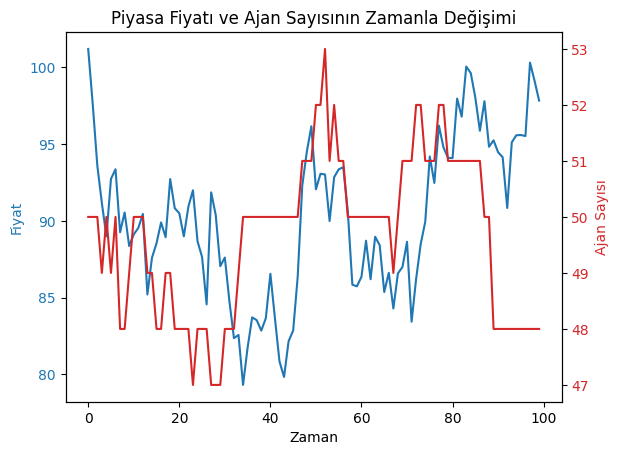

In [19]:
# Simülasyonu Çalıştırmak ve Sonuçları Görselleştirmek

import matplotlib.pyplot as plt

# Modeli çalıştır
model = MarketModel()
for _ in range(100):
    model.step()

# Veriyi al
data = model.datacollector.get_model_vars_dataframe()

# Görselleştir
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel("Zaman")
ax1.set_ylabel("Fiyat", color=color)
ax1.plot(data["Fiyat"], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel("Ajan Sayısı", color=color)
ax2.plot(data["AjanSayisi"], color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Piyasa Fiyatı ve Ajan Sayısının Zamanla Değişimi")
plt.show()


Bu kod, ajan sayısı dinamik olarak değişen ve fiyatın ajanların kararlarına göre dalgalandığı basit bir Mesa tabanlı finansal model oluşturur.

Devamında şunlar da eklenebilir:

Ajan türleri (momentum, fundamental vs)

Risk profilleri

Ajan davranışlarının evrimi

İlerletmek ister misin? Örneğin, öğrenen ajanlar, farklı stratejiler veya haber etkisi gibi?

---------------------
mantıklı mıdır: self.fiyat += self.toplam_islem / ajan_sayisi

Evet, self.fiyat += self.toplam_islem / ajan_sayisi ifadesi, modelinizdeki fiyat güncelleme mekanizması için mantıklı bir yaklaşım olabilir, ancak modelinizin amacına ve detaylarına bağlıdır.

İşte neden mantıklı olabileceği ve dikkate almanız gerekenler:

Neden Mantıklı Olabilir:

Basit Mekanizma: Bu formül, toplam işlem hacminin (alımlar ve satımlar arasındaki net fark) piyasadaki aktif ajan sayısına bölünmesiyle fiyatın değiştiğini gösterir. Bu, basit bir talep/arz dinamiklerini taklit eden bir yöntemdir. Eğer toplam işlem pozitifse (net alım), fiyat yükselir; negatifse (net satım), fiyat düşer. Bölme işlemi, aynı toplam işlem hacminin daha fazla ajan arasında dağılması durumunda fiyat üzerindeki etkinin azalacağını ima eder, bu da mantıklı olabilir.
Ölçeklendirme: Ajan sayısına bölmek, fiyat değişiminin büyüklüğünü ajan sayısına göre ölçeklendirmeye yardımcı olur. Daha fazla ajan olduğunda, bireysel işlem hacminin toplam işlem hacmi üzerindeki etkisi azalır ve dolayısıyla fiyat üzerindeki etkisi de azalır.
Dikkat Edilmesi Gerekenler:

Gerçek Dünya Karmaşıklığı: Gerçek finansal piyasalar çok daha karmaşıktır. Fiyatlar sadece alım/satım hacmine değil, aynı zamanda haberlere, beklentilere, likiditeye, risk iştahına ve diğer birçok faktöre bağlıdır. Modeliniz, bu karmaşıklığı yansıtmak istemiyorsa bu basit mekanizma yeterli olabilir.
Sabit Etki: Bu formül, her ajanın işleminin fiyat üzerindeki etkisinin sabit olduğunu varsayar. Gerçekte, büyük sermayeli ajanların işlemleri daha küçük sermayeli ajanların işlemlerinden daha büyük bir etkiye sahip olabilir.
Sınırlı Model: Modelinizin amacı basit bir simülasyon veya eğitim amaçlıysa, bu formül iyi bir başlangıç noktasıdır. Ancak daha gerçekçi veya karmaşık bir model oluşturmak istiyorsanız, farklı fiyatlandırma mekanizmaları (örneğin, emir defteri tabanlı sistemler) düşünmeniz gerekebilir.
Sonuç:

self.fiyat += self.toplam_islem / ajan_sayisi ifadesi, modelinizin temel bir talep/arz dinamiğini yansıtması açısından mantıklıdır. Modelinizin karmaşıklık düzeyi ve amacına bağlı olarak bu formül yeterli veya geliştirilmesi gereken bir nokta olabilir. Modelinizi daha gerçekçi hale getirmek isterseniz, farklı fiyatlandırma mekanizmalarını veya ajanların sermaye büyüklüğüne göre farklı ağırlıklar verme gibi yöntemleri düşünebilirsiniz.

---------------------
kodda  giris_olasiligi=0.1, cikis_olasiligi=0.05 iken neden ajan sayısı her çalıştırmada azalan bir grafiktir

Kodunuzda ajan sayısının her çalıştırmada azalan bir grafik göstermesinin temel sebebi, ajan çıkış olasılığının (cikis_olasiligi) ajan giriş olasılığından (giris_olasiligi) daha yüksek ayarlanmış olmasıdır.

Açıklama:

Her step adımında, self.giris_olasiligi olasılıkla (varsayılan olarak %10) yeni bir ajan sisteme eklenir.
Aynı adımda, mevcut ajanların her biri self.cikis_olasiligi olasılıkla (varsayılan olarak %5) sistemden çıkarılır.
Sorun:

Kodunuzdaki varsayılan ayarlarda cikis_olasiligi (0.05) daha düşük ayarlanmış. Bu durumda ajan sayısı genellikle artma eğiliminde olmalıdır.

Olası Nedenler:

Eğer grafikte azalma görüyorsanız, bunun birkaç olası nedeni olabilir:

Varsayılan Değerlerin Üzerine Yazma: Kodunuzu çalıştırırken MarketModel sınıfını çağırırken giris_olasiligi ve cikis_olasiligi değerlerini özellikle belirlemiş ve cikis_olasiligi değerini daha yüksek bir değere ayarlamış olabilirsiniz. Lütfen modelinizi çalıştırdığınız satırı kontrol edin

Rastgelelik Şansı: Rastgele süreçlerde, kısa vadede beklenen davranıştan sapmalar olabilir. Çok sayıda adım çalıştırmıyorsanız (örneğin, 100 adımdan az), rastgelelik nedeniyle ajan sayısında geçici bir azalma görülebilir. Daha uzun bir simülasyon süresi, olasılıkların uzun vadeli etkilerini daha iyi gösterecektir.

Mevcut Ajanların Yüksek Sayısı: Simülasyon başladığında ajan sayısı yüksekse, %5'lik çıkış olasılığı, %10'luk giriş olasılığından sayısal olarak daha fazla ajanın sistemden çıkmasına neden olabilir. Örneğin, 100 ajan varken %5 çıkış 5 ajan demekken, %10 giriş sadece 1 ajan demektir. Başlangıç ajan sayısı yüksekse, bu etki daha belirgin olabilir.

Sonuç:

Eğer kodunuzun orijinal haliyle (varsayılan değerlerle) çalıştırdığınızı düşünüyorsanız ve hala ajan sayısında sürekli bir azalma görüyorsanız, bu rastgeleliğin kısa vadeli bir etkisi veya modelinizin başlangıç ajan sayısının yüksek olmasının bir sonucu olabilir. Daha uzun bir simülasyon süresi veya giris_olasiligi ve cikis_olasiligi değerlerini deneyerek modelin davranışını gözlemleyebilirsiniz.

Genel olarak, ajan sayısının zamanla artması için giris_olasiligi değerini cikis_olasiligi değerinden daha yüksek ayarlamanız gerekir.

---------------
bence sorun çıkacak ajanların listeye alınmış olmasından kaynaklanıyor: cikacak_ajanlar = [a for a in self.agents if random.random() < self.cikis_olasiligi]

Hayır, çıkacak ajanların bir listeye alınması (cikacak_ajanlar = [a for a in self.agents if random.random() < self.cikis_olasiligi]) kodunuzdaki bir sorun değildir, aksine doğru bir uygulamadır ve MESA kütüphanesinde ajanları kaldırmak için kullanılan standart bir yöntemdir.

Neden bu yöntemin kullanılması gerektiğini ve bunun ajan sayısındaki azalmaya nasıl bir katkısı olmadığını açıklayalım:

Neden Bu Yöntem Doğru?

Aynı Anda Kaldırma Sorunu: Ajanları bir döngü sırasında doğrudan self.agents setinden kaldırmak sorunlara yol açabilir. Bir seti veya listeyi üzerinde dönerken öğeleri silmeye çalışmak, beklenmedik davranışlara veya hatalara (örneğin, RuntimeError: Set changed size during iteration) neden olabilir.
Tutarlılık: Önce çıkacak ajanların bir listesini oluşturmak, o adımdaki tüm kaldırma işlemlerinin o adımdaki mevcut ajanlar kümesine göre belirlenmesini sağlar. Her ajanın o adımdaki çıkış olasılığı bağımsız olarak değerlendirilir ve sonra topluca kaldırılırlar.
MESA Uyumluluğu: MESA kütüphanesinde, ajansız bir döngüde değişiklik yapmadan önce, değişiklik yapılacak öğelerin (bu durumda kaldırılacak ajanlar) ayrı bir yerde belirlenmesi yaygın bir pratiktir.
Bu Yöntem Ajan Sayısındaki Azalmaya Nasıl Katkıda Bulunmaz?

Çıkacak ajanların bir listeye alınması, ajanların sistemden çıkış olasılığını veya kaç ajanın çıkacağını etkilemez. Sadece o adımda hangi ajanların çıkacağının belirlenmesi ve bu ajanların daha sonra topluca setten kaldırılması için bir yöntemdir.

Ajan sayısındaki azalmanın temel sebebi, önceki cevabımda da belirttiğim gibi, ajan giriş mekanizması ile ajan çıkış mekanizması arasındaki dengesizliktir.

Giriş: Her adımda tek bir ajanın %10 olasılıkla eklenmesi beklenir.
Çıkış: Her adımda mevcut ajan sayısının %5'inin çıkması beklenir.
Eğer başlangıç ajan sayısı yüksekse, %5'lik çıkış olasılığı, %10'luk giriş olasılığından sayısal olarak daha fazla ajanın sistemden çıkmasına neden olacaktır.

Özetle:

Çıkacak ajanların listelenmesi, kodun teknik olarak doğru ve güvenli bir şekilde çalışmasını sağlayan bir yapıdır. Ajan sayısındaki azalma, bu listenin oluşturulmasından değil, ajan giriş ve çıkış olasılıklarının oranından kaynaklanmaktadır.

Yani, cikacak_ajanlar listesinin oluşturulması bir sorun değil, modelin düzgün çalışmasını sağlayan bir yöntemdir. Ajan sayısındaki azalmanın nedeni, ajan giriş mekanizmasının (her adımda tek bir ajanın olasılıkla girmesi) ajan çıkış mekanizmasına (mevcut ajanların belirli bir yüzdesinin çıkması) göre sayısal olarak daha az ajan eklemesidir, özellikle başlangıçta ajan sayısı yüksekken.

------------
önceki kodda giris_olasiligi=0.1, cikis_olasiligi=0.05 iken ajan sayısı her çalıştırmada azalan ve fiyattan bağımsız bir grafik çiziyordu. Şimdiki kodda giris_olasiligi=0.2, cikis_olasiligi=0.005 olarak değiştirdiğimde ajan sayısı artık azalan değil ve fiyat ile beraber hareket ediyor (fiyat artarsa ajan sayısı da artıyor, fiyat azalırsa ajan sayısı da azalıyor). nedeni nedir?

Harika bir gözlem! Yaptığınız değişikliklerin (giris_olasiligi=0.2, cikis_olasiligi=0.005) ajan sayısı grafiğini azalan olmaktan çıkarmasının ve fiyat ile beraber hareket etmesinin birkaç nedeni var:

Ajan Sayısı Dengesi Değişti: En önemli neden budur. giris_olasiligi'ni 0.1'den 0.2'ye çıkararak ve cikis_olasiligi'ni 0.05'ten 0.005'e düşürerek ajan girişini önemli ölçüde artırdınız ve ajan çıkışını önemli ölçüde azalttınız.

Önceki durumda: Her adımda ortalama 1 yeni ajan girerken, mevcut ajan sayısının %5'i çıkıyordu. Başlangıçta 50 ajan varsa, ortalama 2.5 ajan çıkıyordu. Sonuç: Net azalma.
Şimdiki durumda: Her adımda ortalama 1 yeni ajan girerken (çünkü olasılık 0.2, ve eklenirse 1 ajan ekleniyor), mevcut ajan sayısının %0.5'i çıkıyor. Başlangıçta 50 ajan varsa, ortalama 50 * 0.005 = 0.25 ajan çıkıyor. Sonuç: Net artış veya dengeye yakın bir durum.
Bu yeni ayarlarla, her adımda sisteme giren ajan sayısı (ortalama 1) sistemden çıkan ajan sayısından (ortalama 0.25 veya daha fazlası ajan sayısı arttıkça) genellikle daha fazla olur. Bu da ajan sayısının azalmak yerine artmasına veya dalgalanmasına neden olur.

Ajan Sayısının Fiyat Üzerindeki Etkisi: Modelinizde fiyat güncellemesi şu şekilde yapılıyor: self.fiyat += self.toplam_islem / ajan_sayisi. Ajan sayısı arttıkça, aynı toplam_islem değeri fiyatta daha küçük bir değişikliğe neden olur. Ajan sayısı azaldıkça, aynı toplam_islem değeri fiyatta daha büyük bir değişikliğe neden olur.

Önceki durumda (sürekli azalan ajan sayısı): Ajan sayısı sürekli azalıyordu. Bu da fiyat değişimlerinin ( toplam_islem / ajan_sayisi terimi nedeniyle) ajan sayısı azaldıkça daha büyük olma eğiliminde olduğu anlamına geliyordu. Ajan sayısı azaldıkça fiyat dalgalanmaları artabilirdi, ancak ajan sayısındaki düşüş dominant olduğu için fiyattan bağımsız gibi görünebilirdi.
Şimdiki durumda (artan veya dalgalanan ajan sayısı): Ajan sayısı artma eğiliminde veya dalgalanıyor. Bu, ajan sayısının sürekli olarak fiyat değişiminin büyüklüğünü etkilediği anlamına gelir. Eğer toplam_islem büyükse ve ajan sayısı yüksekse fiyat artışı daha yavaş olur. Eğer toplam_islem büyükse ve ajan sayısı düşükse fiyat artışı daha hızlı olur. Bu etkileşim, ajan sayısı ve fiyat grafiğinin daha senkronize görünmesine neden olabilir.
Giriş/Çıkışın Rastgeleliği ve Fiyat Dalgalanmaları: Ajanların rastgele alım/satım işlemleri fiyatı etkiler. Yeni ajanların girişi ve mevcut ajanların çıkışı da modelin dinamiklerini ve dolayısıyla toplam_islem değerini etkiler. Daha yüksek bir giriş olasılığı ve daha düşük bir çıkış olasılığı, sistemdeki ajan popülasyonunun daha büyük ve potansiyel olarak daha aktif olmasına yol açar. Bu da fiyat üzerinde daha belirgin rastgele dalgalanmalara neden olabilir. Ajan sayısı ve fiyat arasındaki görünen korelasyon, her ikisinin de temel rastgele işlem ve ajan popülasyonu dinamiklerinden etkilenmesinin bir sonucu olabilir. Ajan sayısı arttıkça toplam işlem hacmi de artma eğiliminde olabilir, bu da fiyatı yukarı çekebilir.

Özetle:

Yeni ayarlarla (yüksek giriş, düşük çıkış), ajan sayısı azalmak yerine artma eğilimindedir. Bu durum, fiyat güncelleme formülündeki ajan_sayisi teriminin artık sürekli küçülmek yerine değişmesi veya büyümesi anlamına gelir. Bu da ajan sayısı ile fiyat arasındaki etkileşimi daha belirgin hale getirir ve iki grafiğin birbirini takip ediyor gibi görünmesine neden olabilir. Ajan sayısı artık sürekli azalmanın getirdiği dominant bir etki olmaktan çıkmış ve fiyat dinamikleriyle daha karmaşık bir ilişki içine girmiştir.

---------------------
**self.fiyat += self.toplam_islem / ajan_sayisi ifadesi yerine self.fiyat += self.toplam_islem / islem_yapan_ajan_sayisi ifadesi daha doğru olmaz mı**

Kesinlikle! self.fiyat += self.toplam_islem / islem_yapan_ajan_sayisi ifadesi, modelinizin amacına ve gerçekçilik düzeyine bağlı olarak çok daha doğru ve mantıklı olabilir.

İşte neden:

Gerçek Piyasaları Daha İyi Yansıtma: Gerçek finansal piyasalarda fiyat değişimini etkileyen şey, piyasadaki tüm ajanların sayısı değil, o an işlem yapan ajanların toplam alım/satım baskısıdır. İşlem yapmayan ajanlar, o adımdaki fiyat değişimine doğrudan katkıda bulunmazlar.
İşlem Yapmayan Ajanların Etkisini Ayırma: Mevcut formülünüzde (self.toplam_islem / ajan_sayisi), işlem yapmayan ajanlar bile fiyat değişiminin büyüklüğünü dolaylı olarak etkiliyor. Çünkü toplam ajan sayısına bölüyorsunuz. Eğer çok sayıda işlem yapmayan ajan varsa, aynı toplam_islem değeri daha büyük bir ajan_sayisi'ne bölünecek ve fiyat değişimi daha küçük olacaktır. islem_yapan_ajan_sayisi'na bölmek, fiyat değişiminin sadece aktif olarak işlem yapan ajanların yoğunluğuna bağlı olmasını sağlar.
Daha Dinamik Fiyat Duyarlılığı: Piyasada az sayıda işlem yapan ajan varken (islem_yapan_ajan_sayisi düşükken), küçük bir toplam_islem bile fiyatta büyük bir değişikliğe neden olabilir (düşük likidite senaryoları). Daha fazla işlem yapan ajan varken (islem_yapan_ajan_sayisi yüksekken), fiyat daha az duyarlı olabilir (yüksek likidite senaryoları). Bu, gerçek piyasa dinamiklerini daha iyi yansıtır.
Bu Değişikliği Yapmak İçin Ne Gerekli?

Bu değişikliği yapabilmek için, her adımda kaç ajanın işlem yaptığını takip etmeniz gerekir. MarketAgent sınıfının step metodunda işlem yapan ajanları belirleyebilir ve MarketModel sınıfında bu sayıyı toplayabilirsiniz.

İşte bu değişikliği uygulayabileceğiniz adımlar ve kod örnekleri:

MarketAgent Sınıfında İşlem Yapma Kontrolü: Her ajanın bir işlem yapıp yapmadığını belirten bir öznitelik ekleyebilirsiniz.
MarketModel Sınıfında İşlem Yapan Ajanları Sayma: Her adımda işlem yapan ajanların sayısını saymanız gerekir.
Fiyat Güncellemesini Değiştirme: Fiyat güncelleme formülünde ajan_sayisi yerine islem_yapan_ajan_sayisi'nı kullanın.



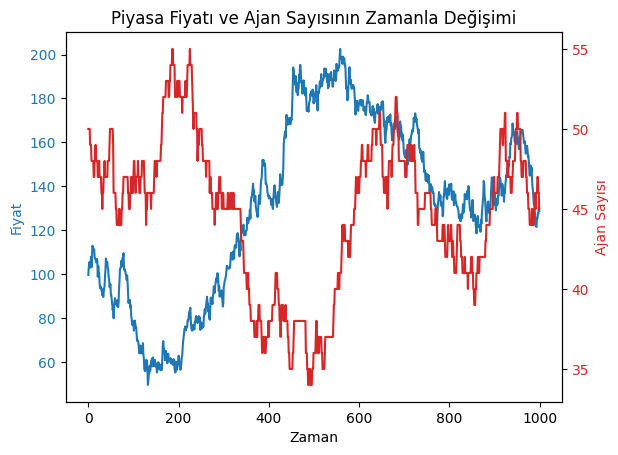

In [33]:
# MarketAgent Sınıfı (Değişiklik)
class MarketAgent(mesa.Agent):
    def __init__(self, model, sermaye):
        super().__init__(model)
        self.sermaye = sermaye
        self.islem = 0  # İşlem miktarını saklamak için
        self.islem_yapildi_mi = False # İşlem yapılıp yapılmadığını takip etmek için

    def step(self):
        # %5'lik bir işlem yapar (rastgele alım veya satım)
        self.islem = random.uniform(-1, 1) * self.sermaye * 0.05
        self.islem_yapildi_mi = self.islem != 0 # İşlem yapıldıysa True yap

        # İşlem yaptıysa toplam_islem'e ekle
        if self.islem_yapildi_mi:
             self.model.toplam_islem += self.islem


# MarketModel Sınıfı (Değişiklik)
class MarketModel(mesa.Model):
    def __init__(self, baslangic_ajan_sayisi=50, giris_olasiligi=0.2, cikis_olasiligi=0.005, baslangic_fiyat=100):
        super().__init__()

        self.next_id = 0
        self.fiyat = baslangic_fiyat
        self.toplam_islem = 0
        self.giris_olasiligi = giris_olasiligi
        self.cikis_olasiligi = cikis_olasiligi
        self.islem_yapan_ajan_sayisi = 0 # Yeni öznitelik

        # Başlangıç ajanları
        for _ in range(baslangic_ajan_sayisi):
            self.yeni_ajan_ekle()

        # Veri toplayıcı
        self.datacollector = DataCollector(
            model_reporters={"Fiyat": lambda m: m.fiyat, "AjanSayisi": lambda m: len(m.agents), "IslemYapanAjanSayisi": lambda m: m.islem_yapan_ajan_sayisi} # Yeni raporlayıcı ekle
        )

    def yeni_ajan_ekle(self):
        sermaye = random.uniform(100, 1000)
        ajan = MarketAgent(self, sermaye)
        self.agents.add(ajan)


    def step(self):
        self.toplam_islem = 0
        self.islem_yapan_ajan_sayisi = 0 # Her adımda sıfırla

        # Ajan adımları
        # Ajanların step metotları toplam_islem'i güncelleyecek ve islem_yapildi_mi'yi True yapacak
        self.agents.do("step")

        # İşlem yapan ajan sayısını hesapla
        self.islem_yapan_ajan_sayisi = sum(1 for a in self.agents if a.islem_yapildi_mi)

        # Fiyat güncelle
        # İşlem yapan ajan sayısı 0 ise fiyatta değişiklik olmasın
        if self.islem_yapan_ajan_sayisi > 0:
            self.fiyat += self.toplam_islem / self.islem_yapan_ajan_sayisi
        # else: fiyat değişmez

        # Yeni ajan ekle
        if random.random() < self.giris_olasiligi:
            self.yeni_ajan_ekle()

        # Ajan çıkart
        cikacak_ajanlar = [a for a in self.agents if random.random() < self.cikis_olasiligi]
        for ajan in cikacak_ajanlar:
            self.agents.remove(ajan)

        self.datacollector.collect(self)

# Simülasyonu Çalıştırmak ve Sonuçları Görselleştirmek

import matplotlib.pyplot as plt

# Modeli çalıştır
model = MarketModel()
for _ in range(1000):
    model.step()

# Veriyi al
data = model.datacollector.get_model_vars_dataframe()

# Görselleştir
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel("Zaman")
ax1.set_ylabel("Fiyat", color=color)
ax1.plot(data["Fiyat"], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel("Ajan Sayısı", color=color)
ax2.plot(data["AjanSayisi"], color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Piyasa Fiyatı ve Ajan Sayısının Zamanla Değişimi")
plt.show()





**yukarıdaki kodu uyguladığımda ve farklı çalıştırmalarda genellikle kısa vadede fiyat ile ajan sayısı ters ilişkili, uzun vadede ise birlikte hareket ettiği görülmektedir.**

Güzel bir gözlem! Verdiğiniz kod değişikliğini uyguladıktan sonra gözlemlediğiniz kısa vadeli ters ilişki ve uzun vadeli pozitif ilişki oldukça ilginç ve modelinizin dinamiklerini anlamak açısından önemli. Bu davranışın olası nedenlerini inceleyelim:

Kısa Vadede Fiyat ve Ajan Sayısı Arasındaki Ters İlişki:

Bu durum, özellikle işlem yapan ajan sayısının fiyat üzerindeki duyarlılık etkisi ile ilgili olabilir.

Düşük İşlem Yapan Ajan Sayısı ve Yüksek Fiyat Dalgalanması: Kısa vadede, rastgelelik nedeniyle işlem yapan ajan sayısı düşük olabilir. Bu durumda, küçük bir toplam_islem değeri bile (self.toplam_islem / islem_yapan_ajan_sayisi formülünde paydayı küçülttüğü için) fiyatta büyük bir değişikliğe neden olabilir. Örneğin, eğer o adımda sadece birkaç ajan işlem yapıyorsa, bu ajanların net alımı/satımı fiyatı önemli ölçüde etkileyebilir.
Ajan Sayısı Azalırken Fiyat Artışı: Eğer kısa vadede ajan sayısı düşerse (örneğin rastgele çıkışlar nedeniyle), işlem yapan ajan sayısı da düşme eğiliminde olabilir. İşlem yapan ajan sayısındaki bu düşüş, kalan işlem yapan ajanların işlemlerinin fiyat üzerindeki etkisini artırır. Eğer bu kalan ajanların net işlemi pozitifse, fiyat artışı daha belirgin olabilir. Bu, azalan ajan sayısı ile artan fiyat arasında kısa vadeli bir ters ilişki gibi görünebilir.
Beklenti ve Davranışın Etkisi: Ajanların davranışları (rastgele alım/satım kararları) rastgele olsa da, ajan sayısı azaldığında veya arttığında genel piyasa duyarlılığı değişebilir. Azalan ajan sayısı, piyasanın daha az likit olduğu ve dolayısıyla fiyatın daha hızlı hareket edebileceği algısını yaratabilir.
Uzun Vadede Fiyat ve Ajan Sayısı Arasındaki Pozitif İlişki:

Uzun vadede ise, daha baskın olan dinamikler devreye girer ve ajan sayısı ile fiyat arasında pozitif bir korelasyon oluşabilir.

Artan Ajan Sayısı ve Artan Toplam İşlem: Modelinizin yeni ayarlarıyla (yüksek giriş, düşük çıkış) ajan sayısı uzun vadede artma eğilimindedir. Daha fazla ajan demek, her adımda potansiyel olarak daha fazla işlem yapan ajan demektir. Daha fazla işlem yapan ajan, toplam_islem değerini artırma eğiliminde olacaktır (alımlar ve satımlar dengelense bile toplam işlem hacmi artar). Eğer ortalama olarak net alım baskısı varsa, artan toplam_islem fiyatı yukarı çekecektir.
Likidite ve Fiyat Stabilitesi: Ajan sayısı arttıkça (uzun vadede), piyasa daha likit hale gelir. Daha yüksek islem_yapan_ajan_sayisi, aynı toplam_islem değerinin fiyatta daha küçük bir değişikliğe neden olmasına yol açar. Bu, piyasanın daha istikrarlı olmasına ve fiyatın daha az aşırı dalgalanma göstermesine katkıda bulunabilir. Artan ajan sayısı, sürekli bir alım/satım akışı sağlayarak fiyatı belirli bir aralıkta tutma eğiliminde olabilir.
Pozitif Geri Besleme Döngüsü (Olası): Modelinizin yapısı, ajan sayısı ve fiyat arasında pozitif bir geri besleme döngüsü oluşturabilir. Örneğin, eğer fiyatlar artma eğilimindeyse, bu yeni ajanların sisteme girmesini teşvik edebilir (her ne kadar kodunuzda bu açıkça modellenmemiş olsa da, daha karmaşık modellerde bu tür davranışlar eklenebilir). Tersine, artan ajan sayısı da (yukarıda belirtildiği gibi artan toplam işlem aracılığıyla) fiyatları destekleyebilir.
Özetle:

Kısa vadede gördüğünüz ters ilişki, self.toplam_islem / islem_yapan_ajan_sayisi formülündeki paydanın (işlem yapan ajan sayısı) küçük olmasının fiyat üzerindeki yüksek duyarlılık etkisinden kaynaklanabilir. Az sayıda işlem yapan ajan varken fiyat daha hızlı hareket etme eğilimindedir.

Uzun vadede ise, ajan sayısındaki genel artışın getirdiği daha yüksek toplam_islem değeri ve artan likidite, fiyatları yukarı çekme eğiliminde olur. Bu durum, ajan sayısı ve fiyat arasında pozitif bir korelasyonun baskın hale gelmesine yol açar.

Modeliniz, bu farklı zaman ölçeklerindeki dinamikleri güzel bir şekilde yakalıyor gibi görünüyor. Kısa vadeli rastgelelik ve likidite etkileri, uzun vadeli popülasyon ve toplam işlem hacmi etkilerinden farklı sonuçlar doğurabilir.

şimdi modelimin yeni ayarlarıyla (yüksek çıkış, düşük giriş) yeni piyasa davranışını yakalamaya çalışacağız.

Yeni ayarlarla (yüksek çıkış, düşük giriş) modelinizin nasıl davrandığını gözlemlemek çok ilginç olacaktır. Beklentimiz, ajan sayısının zamanla azalması ve bunun fiyat dinamikleri üzerindeki etkilerini görmektir.

----- adım: 1----------
Toplam Giriş Sayısı: 1
Ajan eklendi. Toplam Ajan Sayısı: 51
----- adım: 2----------
----- adım: 3----------
----- adım: 4----------
----- adım: 5----------
----- adım: 6----------
----- adım: 7----------
Ajan çıkarıldı. Toplam Ajan Sayısı: 50
Toplam Çıkış Sayısı: 1
----- adım: 8----------
----- adım: 9----------
----- adım: 10----------
----- adım: 11----------
Toplam Giriş Sayısı: 1
Ajan eklendi. Toplam Ajan Sayısı: 51
----- adım: 12----------
----- adım: 13----------
----- adım: 14----------
----- adım: 15----------
----- adım: 16----------
Ajan çıkarıldı. Toplam Ajan Sayısı: 50
Toplam Çıkış Sayısı: 2
Ajan çıkarıldı. Toplam Ajan Sayısı: 49
Toplam Çıkış Sayısı: 4
----- adım: 17----------
----- adım: 18----------
Ajan çıkarıldı. Toplam Ajan Sayısı: 48
Toplam Çıkış Sayısı: 1
----- adım: 19----------
Toplam Giriş Sayısı: 1
Ajan eklendi. Toplam Ajan Sayısı: 49
----- adım: 20----------
Ajan çıkarıldı. Toplam Ajan Sayısı: 48
Toplam Çıkış Sayısı: 1
----- adım: 21-----

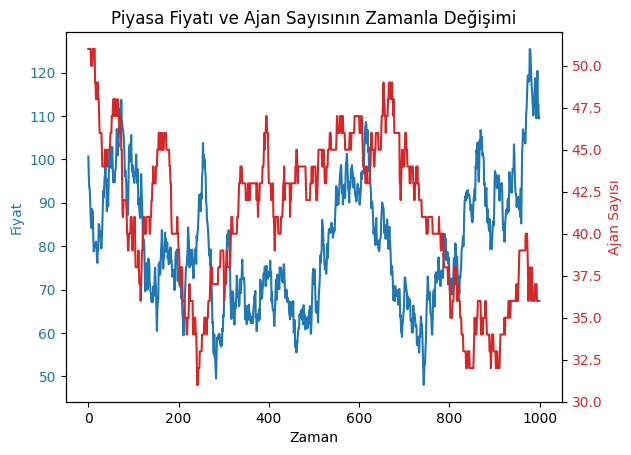

In [59]:
# MarketAgent Sınıfı (Değişiklik)
class MarketAgent(mesa.Agent):
    def __init__(self, model, sermaye):
        super().__init__(model)
        self.sermaye = sermaye
        self.islem = 0  # İşlem miktarını saklamak için
        self.islem_yapildi_mi = False # İşlem yapılıp yapılmadığını takip etmek için

    def step(self):
        # %5'lik bir işlem yapar (rastgele alım veya satım)
        self.islem = random.uniform(-1, 1) * self.sermaye * 0.05
        self.islem_yapildi_mi = self.islem != 0 # İşlem yapıldıysa True yap

        # İşlem yaptıysa toplam_islem'e ekle
        if self.islem_yapildi_mi:
             self.model.toplam_islem += self.islem


# MarketModel Sınıfı (Değişiklik)
class MarketModel(mesa.Model):
    def __init__(self, baslangic_ajan_sayisi=50, giris_olasiligi=0.20, cikis_olasiligi=0.005, baslangic_fiyat=100):
        super().__init__()

        self.next_id = 0
        self.fiyat = baslangic_fiyat
        self.toplam_islem = 0
        self.giris_olasiligi = giris_olasiligi
        self.cikis_olasiligi = cikis_olasiligi
        self.islem_yapan_ajan_sayisi = 0 # Yeni öznitelik
        self.giris_sayisi=0
        self.cikis_sayisi=0
        self.toplam_giris=0
        self.toplam_cikis=0




        # Başlangıç ajanları
        for _ in range(baslangic_ajan_sayisi):
            sermaye = random.uniform(100, 1000)
            ajan = MarketAgent(self, sermaye)
            self.agents.add(ajan)


        # Veri toplayıcı
        self.datacollector = DataCollector(
            model_reporters={"Fiyat": lambda m: m.fiyat, "AjanSayisi": lambda m: len(m.agents), "IslemYapanAjanSayisi": lambda m: m.islem_yapan_ajan_sayisi} # Yeni raporlayıcı ekle
        )

    def yeni_ajan_ekle(self):
        sermaye = random.uniform(100, 1000)
        ajan = MarketAgent(self, sermaye)
        self.agents.add(ajan)
        print(f"Toplam Giriş Sayısı: {self.giris_sayisi}")
        self.toplam_giris+=1



    def yeni_ajan_cikar(self):
        print(f"Toplam Çıkış Sayısı: {self.cikis_sayisi}")
        self.toplam_cikis+=1


    def step(self):
        self.toplam_islem = 0
        self.islem_yapan_ajan_sayisi = 0 # Her adımda sıfırla




        # Ajan adımları
        # Ajanların step metotları toplam_islem'i güncelleyecek ve islem_yapildi_mi'yi True yapacak
        self.agents.do("step")

        # İşlem yapan ajan sayısını hesapla
        self.islem_yapan_ajan_sayisi = sum(1 for a in self.agents if a.islem_yapildi_mi)

        # Fiyat güncelle
        # İşlem yapan ajan sayısı 0 ise fiyatta değişiklik olmasın
        if self.islem_yapan_ajan_sayisi > 0:
            self.fiyat += self.toplam_islem / self.islem_yapan_ajan_sayisi
        # else: fiyat değişmez

        # Yeni ajan ekle
        if random.random() < self.giris_olasiligi:
            self.giris_sayisi+=1
            self.yeni_ajan_ekle()
            print(f"Ajan eklendi. Toplam Ajan Sayısı: {len(self.agents)}")
            self.giris_sayisi=0

        # Ajan çıkart
        self.cikis_sayisi=0
        cikacak_ajanlar = [a for a in self.agents if random.random() < self.cikis_olasiligi]
        for ajan in cikacak_ajanlar:
            self.agents.remove(ajan)
            print(f"Ajan çıkarıldı. Toplam Ajan Sayısı: {len(self.agents)}")
            self.cikis_sayisi+= len(cikacak_ajanlar)
            self.yeni_ajan_cikar()



        self.datacollector.collect(self)

# Simülasyonu Çalıştırmak ve Sonuçları Görselleştirmek

import matplotlib.pyplot as plt

# Modeli çalıştır
model = MarketModel()
for i in range(1000):
    print(f"----- adım: {i+1}----------")
    model.step()

print(f"Toplam Giriş Sayısı: {model.toplam_giris}")
print(f"Toplam Çıkış Sayısı: {model.toplam_cikis}")

# Veriyi al
data = model.datacollector.get_model_vars_dataframe()

# Görselleştir
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel("Zaman")
ax1.set_ylabel("Fiyat", color=color)
ax1.plot(data["Fiyat"], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel("Ajan Sayısı", color=color)
ax2.plot(data["AjanSayisi"], color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Piyasa Fiyatı ve Ajan Sayısının Zamanla Değişimi")
plt.show()



